In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display, HTML
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 17,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

PALETTE = ["#6C5CE7", "#00B894", "#0984E3", "#E84393", "#FDCB6E", "#D63031", "#00CEC9"]
VOCAB_SIZE = 10000
MAX_LEN = 50
EMBEDDING_DIM = 2
RNN_UNITS = 32
EPOCHS = 5
BATCH_SIZE = 512
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

display(HTML("""
<div style="padding:20px;border-radius:18px;background:linear-gradient(135deg,#6C5CE7,#00B894);color:white;font-family:Arial">
<div style="font-size:28px;font-weight:800">IMDB Sentiment Analysis with SimpleRNN</div>
<div style="font-size:15px;margin-top:8px">Integer Encoding → SimpleRNN and Embedding → SimpleRNN</div>
</div>
"""))

In [2]:
docs = [
    "go india",
    "india india",
    "hip hip hurray",
    "jeetega bhai jeetega india jeetega",
    "bharat mata ki jai",
    "kohli kohli",
    "sachin sachin",
    "dhoni dhoni",
    "modi ji ki jai",
    "inquilab zindabad"
]

toy_tokenizer = Tokenizer(oov_token="<OOV>")
toy_tokenizer.fit_on_texts(docs)

toy_word_index = toy_tokenizer.word_index
toy_word_counts = dict(toy_tokenizer.word_counts)
toy_sequences = toy_tokenizer.texts_to_sequences(docs)
toy_padded = pad_sequences(toy_sequences, padding="post")

toy_vocab_size = len(toy_word_index) + 1
toy_max_len = toy_padded.shape[1]

display(HTML(f"""
<div style="padding:15px;border-radius:14px;background:#F8F9FA;border-left:6px solid #6C5CE7">
<b>Toy text pipeline</b><br>
Vocabulary size: {toy_vocab_size}<br>
Documents: {toy_tokenizer.document_count}<br>
Padded sequence length: {toy_max_len}
</div>
"""))

display(pd.DataFrame({
    "word": list(toy_word_counts.keys()),
    "index": [toy_word_index[w] for w in toy_word_counts],
    "count": list(toy_word_counts.values())
}).sort_values(["count", "index"], ascending=[False, True]).reset_index(drop=True))

,word,index,count
0,india,2,4
1,jeetega,3,3
2,hip,4,2
3,ki,5,2
4,jai,6,2
5,kohli,7,2
6,sachin,8,2
7,dhoni,9,2
8,go,10,1
9,hurray,11,1


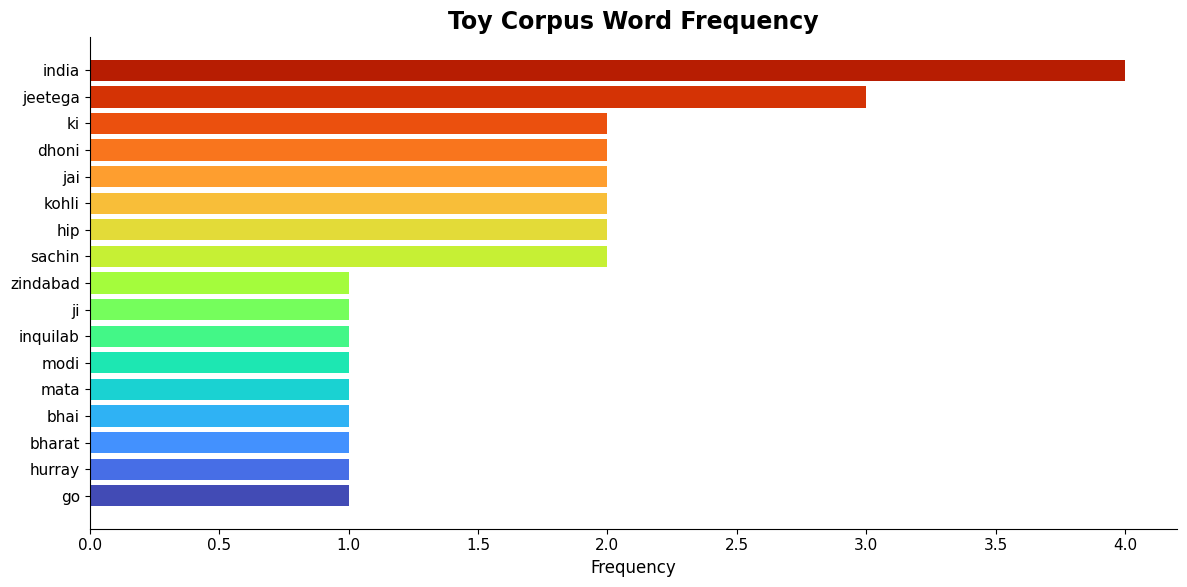

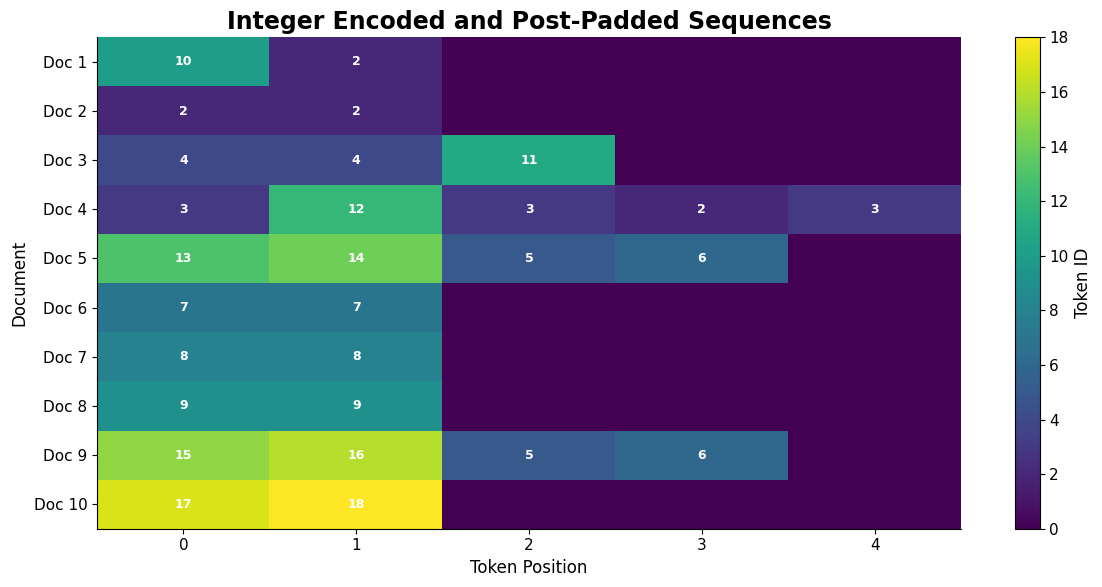

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
word_df = (
    pd.DataFrame({"word": list(toy_word_counts.keys()), "count": list(toy_word_counts.values())})
    .sort_values("count", ascending=True)
)
colors = plt.cm.turbo(np.linspace(0.08, 0.92, len(word_df)))
ax.barh(word_df["word"], word_df["count"], color=colors)
ax.set_title("Toy Corpus Word Frequency")
ax.set_xlabel("Frequency")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(toy_padded, cmap="viridis", aspect="auto")
ax.set_title("Integer Encoded and Post-Padded Sequences")
ax.set_xlabel("Token Position")
ax.set_ylabel("Document")
ax.set_xticks(range(toy_padded.shape[1]))
ax.set_yticks(range(len(docs)))
ax.set_yticklabels([f"Doc {i+1}" for i in range(len(docs))])
for i in range(toy_padded.shape[0]):
    for j in range(toy_padded.shape[1]):
        value = toy_padded[i, j]
        if value:
            ax.text(j, i, str(value), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
fig.colorbar(im, ax=ax, label="Token ID")
plt.tight_layout()
plt.show()

,embedding_x,embedding_y
<PAD>,0.0358,0.0163
<OOV>,-0.0141,0.0450
india,-0.0422,0.0152
jeetega,0.0470,-0.0332
hip,0.0024,0.0131
ki,-0.0414,-0.0054
jai,0.0466,-0.0030
kohli,0.0003,0.0266
sachin,-0.0481,-0.0308
dhoni,0.0014,-0.0434


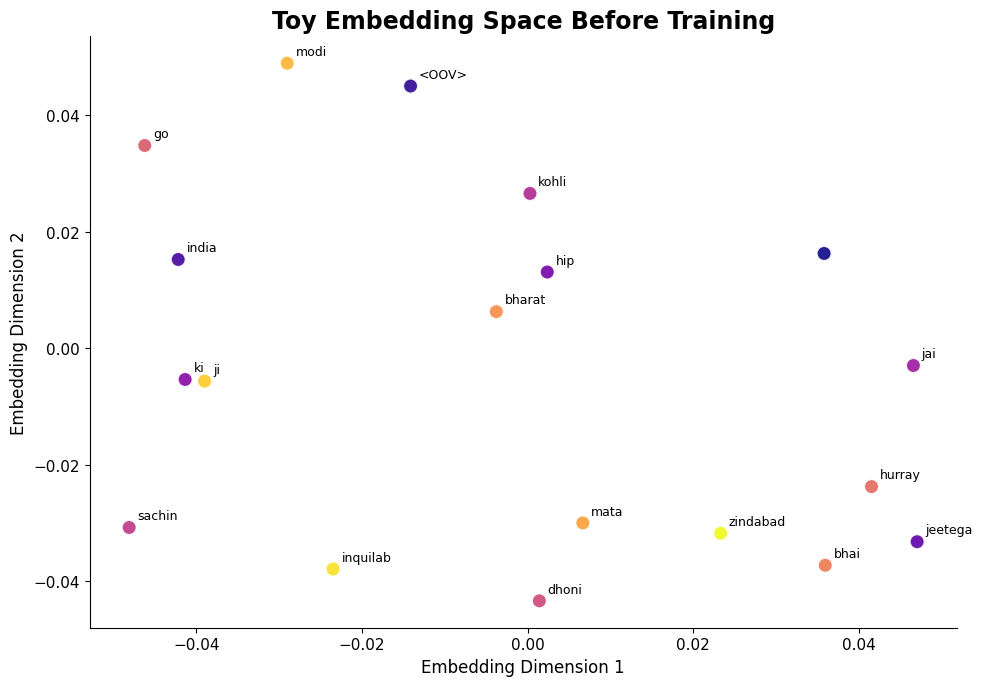

In [4]:
toy_embedding_model = Sequential([
    Input(shape=(toy_max_len,)),
    Embedding(input_dim=toy_vocab_size, output_dim=EMBEDDING_DIM)
])

toy_embedding_output = toy_embedding_model(toy_padded)

display(pd.DataFrame(
    toy_embedding_model.get_weights()[0],
    index=["<PAD>"] + [next((w for w, idx in toy_word_index.items() if idx == i), f"<ID_{i}>") for i in range(1, toy_vocab_size)],
    columns=["embedding_x", "embedding_y"]
).round(4))

fig, ax = plt.subplots(figsize=(10, 7))
toy_weights = toy_embedding_model.get_weights()[0]
ax.scatter(toy_weights[:, 0], toy_weights[:, 1], s=110, c=np.arange(len(toy_weights)), cmap="plasma", alpha=0.9, edgecolor="white", linewidth=1.2)
for i in range(1, len(toy_weights)):
    word = next((w for w, idx in toy_word_index.items() if idx == i), f"ID_{i}")
    ax.annotate(word, (toy_weights[i, 0], toy_weights[i, 1]), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_title("Toy Embedding Space Before Training")
ax.set_xlabel("Embedding Dimension 1")
ax.set_ylabel("Embedding Dimension 2")
plt.tight_layout()
plt.show()

In [5]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

if MAX_TRAIN_SAMPLES is not None:
    X_train = X_train[:MAX_TRAIN_SAMPLES]
    y_train = y_train[:MAX_TRAIN_SAMPLES]

if MAX_TEST_SAMPLES is not None:
    X_test = X_test[:MAX_TEST_SAMPLES]
    y_test = y_test[:MAX_TEST_SAMPLES]

train_raw_lengths = np.array([len(x) for x in X_train])
test_raw_lengths = np.array([len(x) for x in X_test])

X_train_pad = pad_sequences(X_train, padding="post", maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test, padding="post", maxlen=MAX_LEN)

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

display(HTML(f"""
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;font-family:Arial">
<div style="padding:16px;border-radius:14px;background:#EEF2FF"><b>Train</b><br>{len(X_train):,}</div>
<div style="padding:16px;border-radius:14px;background:#ECFDF5"><b>Test</b><br>{len(X_test):,}</div>
<div style="padding:16px;border-radius:14px;background:#FFF7ED"><b>Max tokens</b><br>{VOCAB_SIZE:,}</div>
<div style="padding:16px;border-radius:14px;background:#FDF2F8"><b>Sequence length</b><br>{MAX_LEN}</div>
</div>
"""))

display(pd.DataFrame({
    "split": ["train", "test"],
    "samples": [len(X_train), len(X_test)],
    "positive": [int(y_train.sum()), int(y_test.sum())],
    "negative": [int((1-y_train).sum()), int((1-y_test).sum())]
}))

print("First encoded review:", X_train[0][:30])
print("First padded review:", X_train_pad[0][:30])
print("First label:", y_train[0])

,split,samples,positive,negative
0,train,25000,12500,12500
1,test,25000,12500,12500


First encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]
First padded review: [2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5  144   30 5535   18   51   36   28  224   92   25  104
    4  226]
First label: 1


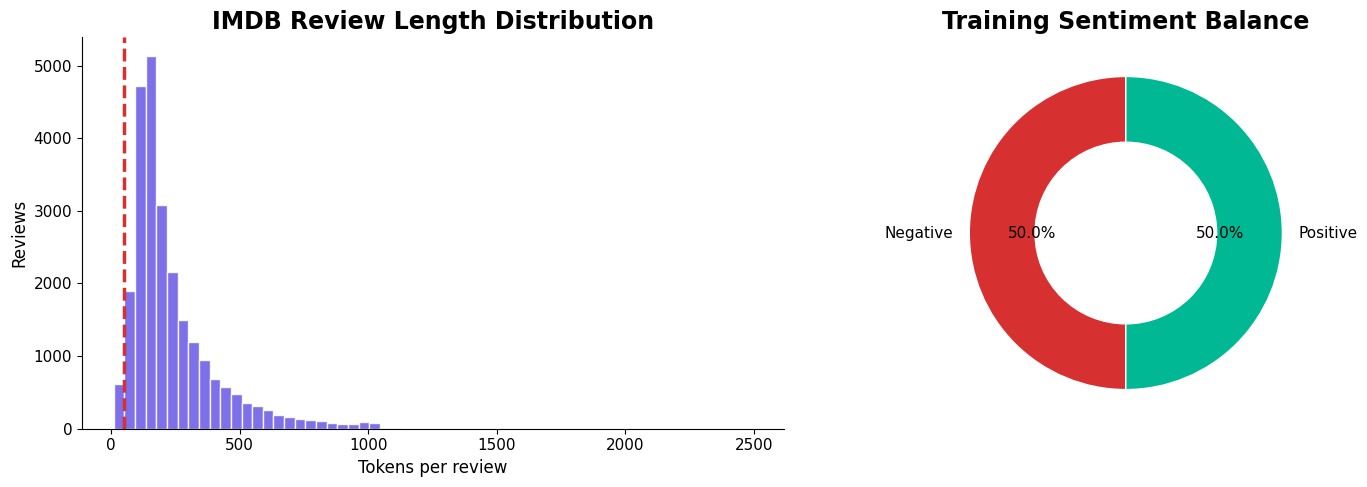

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_raw_lengths, bins=60, color=PALETTE[0], alpha=0.88, edgecolor="white")
axes[0].axvline(MAX_LEN, color=PALETTE[5], linestyle="--", linewidth=2.5)
axes[0].set_title("IMDB Review Length Distribution")
axes[0].set_xlabel("Tokens per review")
axes[0].set_ylabel("Reviews")

class_counts = np.bincount(y_train)
axes[1].pie(
    class_counts,
    labels=["Negative", "Positive"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[PALETTE[5], PALETTE[1]],
    wedgeprops={"width": 0.42, "edgecolor": "white"}
)
axes[1].set_title("Training Sentiment Balance")

plt.tight_layout()
plt.show()

In [7]:
X_train_integer = X_train_pad.astype("float32")[..., np.newaxis]
X_test_integer = X_test_pad.astype("float32")[..., np.newaxis]

integer_model = Sequential([
    Input(shape=(MAX_LEN, 1)),
    SimpleRNN(RNN_UNITS, return_sequences=False),
    Dense(1, activation="sigmoid")
])

integer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

integer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
integer_history = integer_model.fit(
    X_train_integer,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_integer, y_test),
    verbose=1
)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5024 - loss: 0.7124 - val_accuracy: 0.5032 - val_loss: 0.6989
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5069 - loss: 0.6943 - val_accuracy: 0.5041 - val_loss: 0.6936
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5078 - loss: 0.6925 - val_accuracy: 0.5042 - val_loss: 0.6936
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5094 - loss: 0.6923 - val_accuracy: 0.5055 - val_loss: 0.6936
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5083 - loss: 0.6922 - val_accuracy: 0.5101 - val_loss: 0.6937


In [9]:
embedding_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS, return_sequences=False),
    Dense(1, activation="sigmoid")
])

embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

embedding_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 2)          │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
embedding_history = embedding_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5450 - loss: 0.6865 - val_accuracy: 0.6520 - val_loss: 0.6619
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7229 - loss: 0.5559 - val_accuracy: 0.7427 - val_loss: 0.5298
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8110 - loss: 0.4310 - val_accuracy: 0.7911 - val_loss: 0.4492
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8486 - loss: 0.3642 - val_accuracy: 0.7908 - val_loss: 0.4433
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8595 - loss: 0.3413 - val_accuracy: 0.7821 - val_loss: 0.4780


,Model,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss
0,Integer Encoding,0.5083,0.5101,0.6922,0.6937
1,Embedding,0.8595,0.7821,0.3413,0.4780


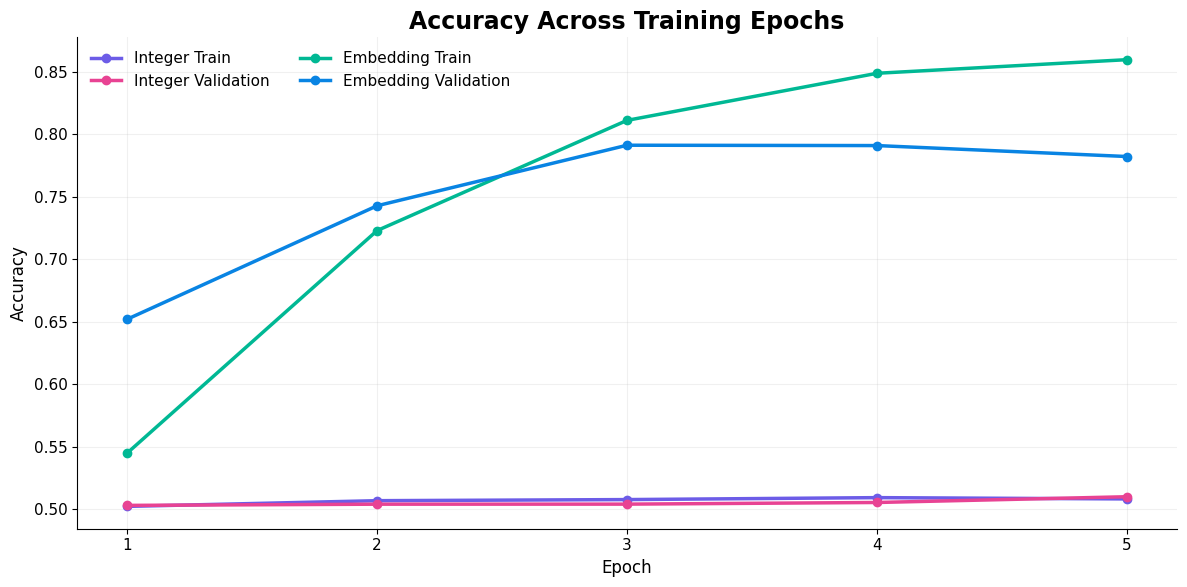

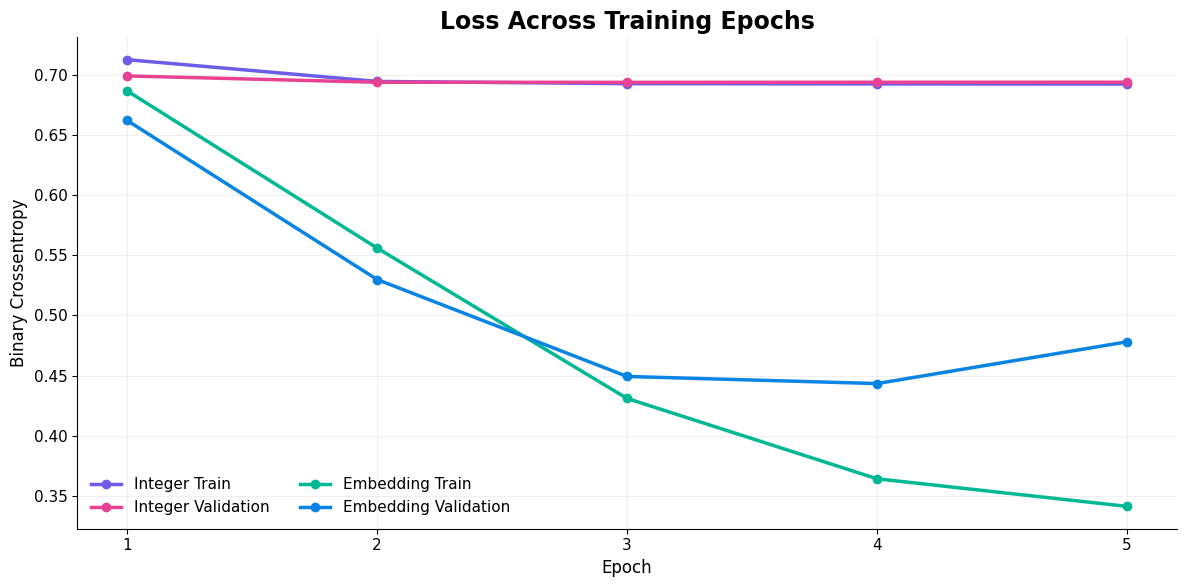

In [11]:
def history_frame(history, name):
    frame = pd.DataFrame(history.history).reset_index().rename(columns={"index": "epoch"})
    frame["epoch"] = frame["epoch"] + 1
    frame["model"] = name
    return frame

integer_history_df = history_frame(integer_history, "Integer Encoding")
embedding_history_df = history_frame(embedding_history, "Embedding")

metrics_df = pd.DataFrame({
    "Model": ["Integer Encoding", "Embedding"],
    "Final Train Accuracy": [integer_history.history["accuracy"][-1], embedding_history.history["accuracy"][-1]],
    "Final Validation Accuracy": [integer_history.history["val_accuracy"][-1], embedding_history.history["val_accuracy"][-1]],
    "Final Train Loss": [integer_history.history["loss"][-1], embedding_history.history["loss"][-1]],
    "Final Validation Loss": [integer_history.history["val_loss"][-1], embedding_history.history["val_loss"][-1]]
})

display(metrics_df.style.format({
    "Final Train Accuracy": "{:.4f}",
    "Final Validation Accuracy": "{:.4f}",
    "Final Train Loss": "{:.4f}",
    "Final Validation Loss": "{:.4f}"
}).background_gradient(cmap="viridis", subset=metrics_df.columns[1:]))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(integer_history.history["accuracy"], marker="o", linewidth=2.5, color=PALETTE[0], label="Integer Train")
ax.plot(integer_history.history["val_accuracy"], marker="o", linewidth=2.5, color=PALETTE[3], label="Integer Validation")
ax.plot(embedding_history.history["accuracy"], marker="o", linewidth=2.5, color=PALETTE[1], label="Embedding Train")
ax.plot(embedding_history.history["val_accuracy"], marker="o", linewidth=2.5, color=PALETTE[2], label="Embedding Validation")
ax.set_title("Accuracy Across Training Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(range(EPOCHS))
ax.set_xticklabels(range(1, EPOCHS + 1))
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(integer_history.history["loss"], marker="o", linewidth=2.5, color=PALETTE[0], label="Integer Train")
ax.plot(integer_history.history["val_loss"], marker="o", linewidth=2.5, color=PALETTE[3], label="Integer Validation")
ax.plot(embedding_history.history["loss"], marker="o", linewidth=2.5, color=PALETTE[1], label="Embedding Train")
ax.plot(embedding_history.history["val_loss"], marker="o", linewidth=2.5, color=PALETTE[2], label="Embedding Validation")
ax.set_title("Loss Across Training Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Crossentropy")
ax.set_xticks(range(EPOCHS))
ax.set_xticklabels(range(1, EPOCHS + 1))
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

,Metric,Integer Encoding,Embedding
0,Training Accuracy,0.5083,0.8595
1,Validation Accuracy,0.5101,0.7821
2,Training Loss,0.6922,0.3413
3,Validation Loss,0.6937,0.4780


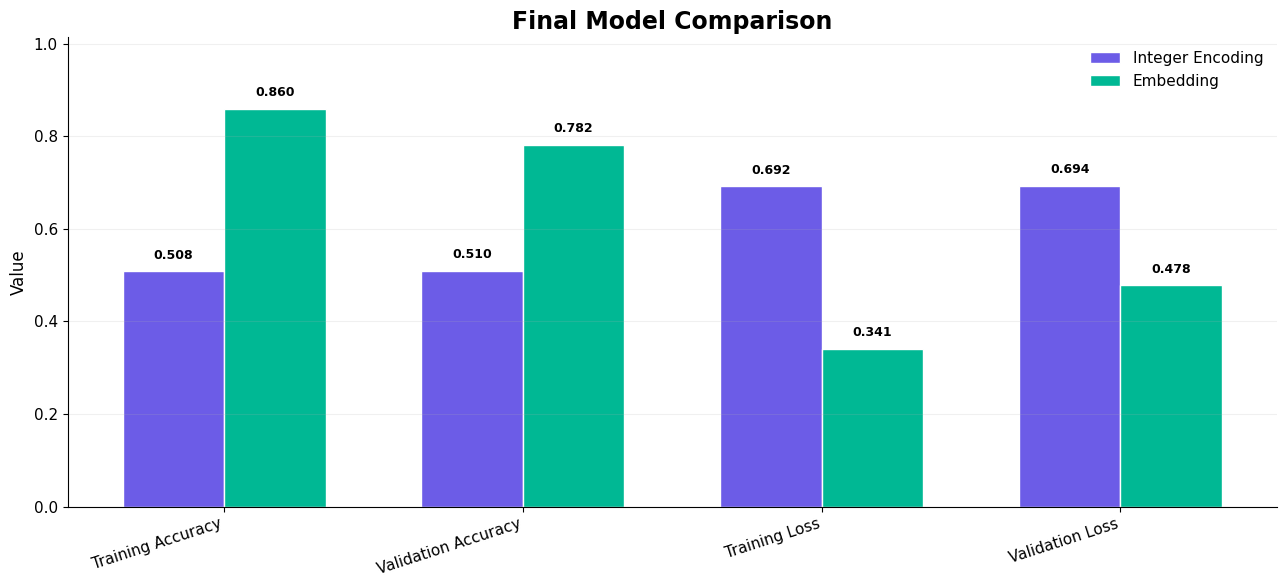

In [12]:
comparison = pd.DataFrame({
    "Metric": ["Training Accuracy", "Validation Accuracy", "Training Loss", "Validation Loss"],
    "Integer Encoding": [
        integer_history.history["accuracy"][-1],
        integer_history.history["val_accuracy"][-1],
        integer_history.history["loss"][-1],
        integer_history.history["val_loss"][-1]
    ],
    "Embedding": [
        embedding_history.history["accuracy"][-1],
        embedding_history.history["val_accuracy"][-1],
        embedding_history.history["loss"][-1],
        embedding_history.history["val_loss"][-1]
    ]
})

display(comparison.style.format({
    "Integer Encoding": "{:.4f}",
    "Embedding": "{:.4f}"
}).background_gradient(cmap="plasma", subset=["Integer Encoding", "Embedding"]))

x = np.arange(len(comparison))
width = 0.34

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, comparison["Integer Encoding"], width, label="Integer Encoding", color=PALETTE[0], edgecolor="white")
bars2 = ax.bar(x + width/2, comparison["Embedding"], width, label="Embedding", color=PALETTE[1], edgecolor="white")

ax.set_title("Final Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Metric"], rotation=18, ha="right")
ax.set_ylabel("Value")
ax.set_ylim(0, max(1.0, comparison[["Integer Encoding", "Embedding"]].max().max() * 1.18))
ax.legend(frameon=False)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

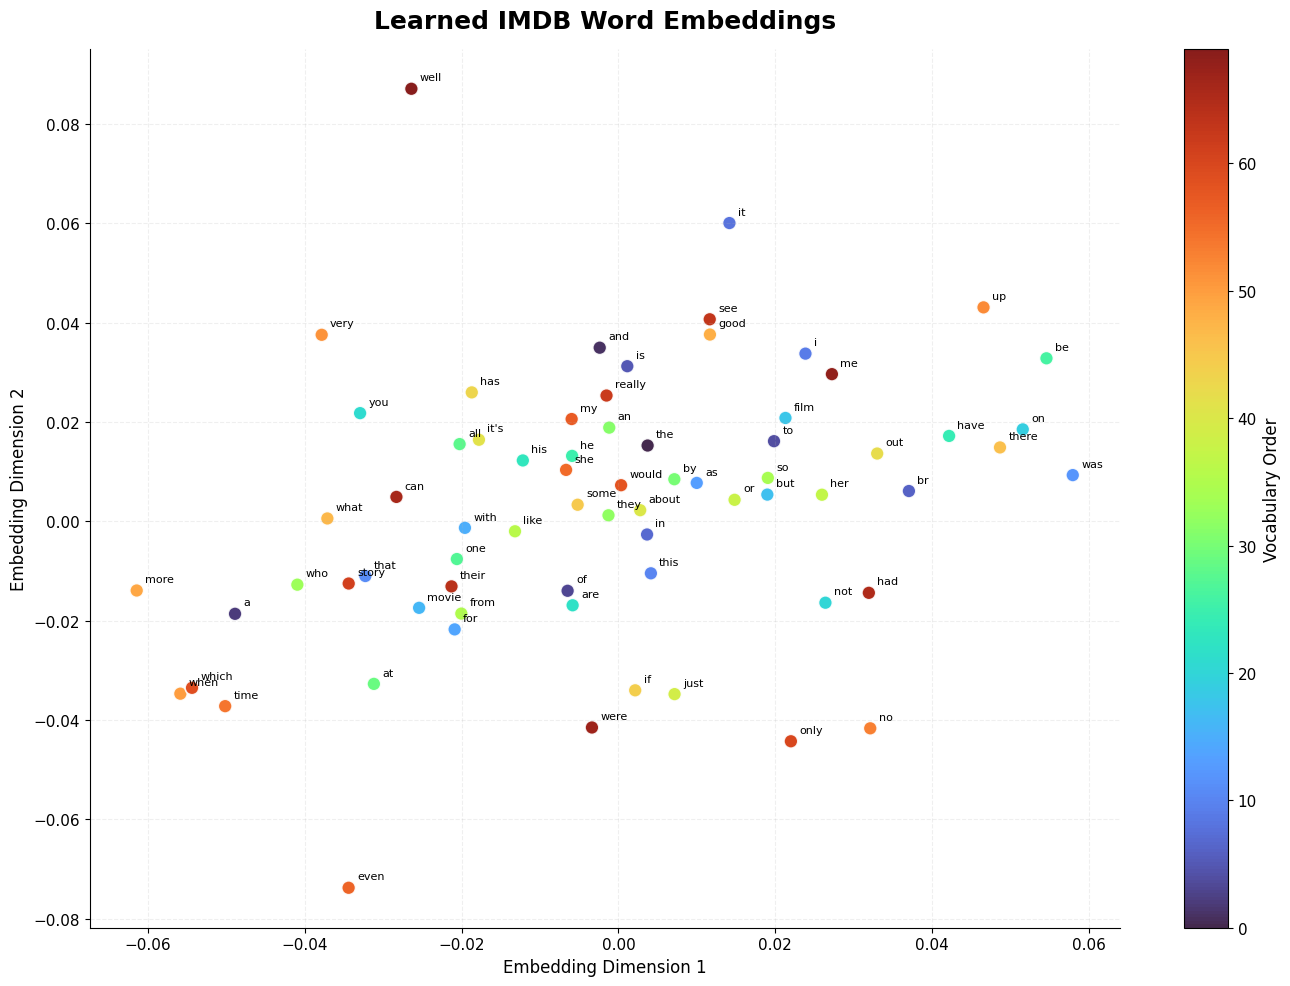

In [13]:
embedding_layer = next(
    layer for layer in embedding_model.layers
    if isinstance(layer, tf.keras.layers.Embedding)
)

embedding_weights = embedding_layer.get_weights()[0]

imdb_word_index = imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in imdb_word_index.items()
}

selected_ids = [
    i for i in range(4, min(VOCAB_SIZE, embedding_weights.shape[0]))
    if i in reverse_word_index
]

selected_ids = selected_ids[:70]

plot_weights = embedding_weights[selected_ids]

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    plot_weights[:, 0],
    plot_weights[:, 1],
    c=np.arange(len(plot_weights)),
    cmap="turbo",
    s=100,
    alpha=0.9,
    edgecolor="white",
    linewidth=1.2
)

for idx, word_id in enumerate(selected_ids):
    ax.annotate(
        reverse_word_index[word_id],
        (
            plot_weights[idx, 0],
            plot_weights[idx, 1]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title(
    "Learned IMDB Word Embeddings",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Embedding Dimension 1",
    fontsize=12
)

ax.set_ylabel(
    "Embedding Dimension 2",
    fontsize=12
)

ax.grid(
    alpha=0.2,
    linestyle="--"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Vocabulary Order"
)

plt.tight_layout()
plt.show()

In [14]:
integer_test_prob = integer_model.predict(X_test_integer, batch_size=BATCH_SIZE, verbose=0).ravel()
embedding_test_prob = embedding_model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0).ravel()

prediction_df = pd.DataFrame({
    "True Label": y_test,
    "Integer Probability": integer_test_prob,
    "Integer Prediction": (integer_test_prob >= 0.5).astype(int),
    "Embedding Probability": embedding_test_prob,
    "Embedding Prediction": (embedding_test_prob >= 0.5).astype(int)
})

integer_accuracy = (prediction_df["True Label"] == prediction_df["Integer Prediction"]).mean()
embedding_accuracy = (prediction_df["True Label"] == prediction_df["Embedding Prediction"]).mean()

display(HTML(f"""
<div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;font-family:Arial">
<div style="padding:18px;border-radius:16px;background:#EEF2FF"><b>Integer Encoding Test Accuracy</b><div style="font-size:30px;font-weight:800;color:#6C5CE7">{integer_accuracy:.2%}</div></div>
<div style="padding:18px;border-radius:16px;background:#ECFDF5"><b>Embedding Test Accuracy</b><div style="font-size:30px;font-weight:800;color:#00B894">{embedding_accuracy:.2%}</div></div>
</div>
"""))

display(prediction_df.head(12).style.format({
    "Integer Probability": "{:.3f}",
    "Embedding Probability": "{:.3f}"
}).background_gradient(cmap="coolwarm", subset=["Integer Probability", "Embedding Probability"]))

,True Label,Integer Probability,Integer Prediction,Embedding Probability,Embedding Prediction
0,0,0.509,1,0.109,0
1,1,0.509,1,0.944,1
2,1,0.509,1,0.943,1
3,0,0.509,1,0.807,1
4,1,0.508,1,0.965,1
5,1,0.509,1,0.553,1
6,1,0.509,1,0.933,1
7,0,0.484,0,0.080,0
8,0,0.509,1,0.805,1
9,1,0.509,1,0.689,1


In [15]:
final_summary = pd.DataFrame({
    "Component": [
        "Tokenizer",
        "Integer Encoding Input",
        "Embedding Input",
        "RNN Units",
        "Sequence Length",
        "Vocabulary Size",
        "Epochs",
        "Batch Size"
    ],
    "Value": [
        "Keras Tokenizer / IMDB encoded sequences",
        "(samples, 50, 1)",
        "(samples, 50)",
        RNN_UNITS,
        MAX_LEN,
        VOCAB_SIZE,
        EPOCHS,
        BATCH_SIZE
    ]
})

display(final_summary.style.set_properties(**{
    "font-size": "12px",
    "padding": "8px"
}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#6C5CE7"), ("color", "white"), ("font-weight", "bold")]},
    {"selector": "tr:nth-child(even)", "props": [("background-color", "#F7F7FB")]}
]))

,Component,Value
0,Tokenizer,Keras Tokenizer / IMDB encoded sequences
1,Integer Encoding Input,"(samples, 50, 1)"
2,Embedding Input,"(samples, 50)"
3,RNN Units,32
4,Sequence Length,50
5,Vocabulary Size,10000
6,Epochs,5
7,Batch Size,512
